In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import yaml

In [2]:
PROJECT_ROOT = Path(
    r"E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna"
)

with open(
    PROJECT_ROOT / "environment.yml",
    "r",
    encoding="utf-8"
) as file:
    config = yaml.safe_load(file)

print("Configuration loaded successfully.")
print("Project root:", PROJECT_ROOT)

Configuration loaded successfully.
Project root: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna


In [3]:
BMD = PROJECT_ROOT / config["paths"]["bmd"]
PROCESSED_DATA = PROJECT_ROOT / config["paths"]["processed_data"]

GAUGE_OUTPUT = PROCESSED_DATA / "gauge"

GAUGE_OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)

print("BMD folder:", BMD)
print("Gauge output:", GAUGE_OUTPUT)

BMD folder: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\Raw\BMD_Data
Gauge output: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\gauge


In [4]:
bmd_files = sorted(
    file_path
    for file_path in BMD.iterdir()
    if file_path.is_file()
)

for number, file_path in enumerate(
    bmd_files,
    start=1
):
    print(f"{number:2d}. {file_path.name}")

 1. BMD.cpg
 2. BMD.dbf
 3. BMD.prj
 4. BMD.sbn
 5. BMD.sbx
 6. BMD.shp
 7. BMD.shx
 8. CL503.xlsx
 9. CL504.xlsx
10. CL509.xlsx
11. CL510.xlsx
12. CL515.xlsx
13. CL517.xlsx
14. Khulna_Monthly_Rainfall_2017_2022_with_LatLong.xls


In [6]:
shapefiles = sorted(
    BMD.glob("*.shp")
)

if not shapefiles:
    raise FileNotFoundError(
        f"No shapefile found in {BMD}"
    )

station_shapefile = shapefiles[0]

stations_gdf = gpd.read_file(
    station_shapefile
)

print("Station shapefile:", station_shapefile.name)
print("CRS:", stations_gdf.crs)
print("Number of stations:", len(stations_gdf))

stations_gdf

Station shapefile: BMD.shp
CRS: EPSG:4326
Number of stations: 432


,Station_ID,Station,Latitude,Longitude,Year,Month,Rainfall_m,geometry
0,CL503,Chalna,22.6012,89.5195,2017.0,1.0,0.0,POINT (89.5195 22.6012)
1,CL503,Chalna,22.6012,89.5195,2017.0,2.0,0.0,POINT (89.5195 22.6012)
2,CL503,Chalna,22.6012,89.5195,2017.0,3.0,345.0,POINT (89.5195 22.6012)
3,CL503,Chalna,22.6012,89.5195,2017.0,4.0,270.0,POINT (89.5195 22.6012)
4,CL503,Chalna,22.6012,89.5195,2017.0,5.0,783.0,POINT (89.5195 22.6012)
...,...,...,...,...,...,...,...,...
427,CL517,Rupsa,22.7900,89.5900,2022.0,8.0,330.3,POINT (89.59 22.79)
428,CL517,Rupsa,22.7900,89.5900,2022.0,9.0,135.1,POINT (89.59 22.79)
429,CL517,Rupsa,22.7900,89.5900,2022.0,10.0,151.7,POINT (89.59 22.79)
430,CL517,Rupsa,22.7900,89.5900,2022.0,11.0,13.2,POINT (89.59 22.79)


In [7]:
print(stations_gdf.columns.tolist())

stations_gdf.info()

['Station_ID', 'Station', 'Latitude', 'Longitude', 'Year', 'Month', 'Rainfall_m', 'geometry']
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Station_ID  432 non-null    object  
 1   Station     432 non-null    object  
 2   Latitude    432 non-null    float64 
 3   Longitude   432 non-null    float64 
 4   Year        432 non-null    float64 
 5   Month       432 non-null    float64 
 6   Rainfall_m  432 non-null    float64 
 7   geometry    432 non-null    geometry
dtypes: float64(5), geometry(1), object(2)
memory usage: 27.1+ KB


In [8]:
gauge_df = stations_gdf.copy()

gauge_df = gauge_df.rename(
    columns={
        "Station_ID": "station_id",
        "Station": "station_name",
        "Latitude": "latitude",
        "Longitude": "longitude",
        "Year": "year",
        "Month": "month",
        "Rainfall_m": "rainfall_mm",
    }
)

gauge_df.head()

,station_id,station_name,latitude,longitude,year,month,rainfall_mm,geometry
0,CL503,Chalna,22.6012,89.5195,2017.0,1.0,0.0,POINT (89.5195 22.6012)
1,CL503,Chalna,22.6012,89.5195,2017.0,2.0,0.0,POINT (89.5195 22.6012)
2,CL503,Chalna,22.6012,89.5195,2017.0,3.0,345.0,POINT (89.5195 22.6012)
3,CL503,Chalna,22.6012,89.5195,2017.0,4.0,270.0,POINT (89.5195 22.6012)
4,CL503,Chalna,22.6012,89.5195,2017.0,5.0,783.0,POINT (89.5195 22.6012)


In [9]:
numeric_columns = [
    "latitude",
    "longitude",
    "year",
    "month",
    "rainfall_mm",
]

for column in numeric_columns:
    gauge_df[column] = pd.to_numeric(
        gauge_df[column],
        errors="coerce"
    )

gauge_df["station_id"] = (
    gauge_df["station_id"]
    .astype(str)
    .str.strip()
)

gauge_df["station_name"] = (
    gauge_df["station_name"]
    .astype(str)
    .str.strip()
)

gauge_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   station_id    432 non-null    object  
 1   station_name  432 non-null    object  
 2   latitude      432 non-null    float64 
 3   longitude     432 non-null    float64 
 4   year          432 non-null    float64 
 5   month         432 non-null    float64 
 6   rainfall_mm   432 non-null    float64 
 7   geometry      432 non-null    geometry
dtypes: float64(5), geometry(1), object(2)
memory usage: 27.1+ KB


In [11]:
gauge_df["year"] = gauge_df["year"].astype("Int64")
gauge_df["month"] = gauge_df["month"].astype("Int64")

gauge_df[["year", "month"]]

,year,month
0,2017,1
1,2017,2
2,2017,3
3,2017,4
4,2017,5
...,...,...
427,2022,8
428,2022,9
429,2022,10
430,2022,11


In [12]:
gauge_df["date"] = pd.to_datetime(
    {
        "year": gauge_df["year"],
        "month": gauge_df["month"],
        "day": 1,
    },
    errors="coerce"
)

gauge_df[
    [
        "station_id",
        "station_name",
        "year",
        "month",
        "date",
        "rainfall_mm",
    ]
].head()

,station_id,station_name,year,month,date,rainfall_mm
0,CL503,Chalna,2017,1,2017-01-01,0.0
1,CL503,Chalna,2017,2,2017-02-01,0.0
2,CL503,Chalna,2017,3,2017-03-01,345.0
3,CL503,Chalna,2017,4,2017-04-01,270.0
4,CL503,Chalna,2017,5,2017-05-01,783.0


In [13]:
gauge_df = gauge_df[
    gauge_df["date"].between(
        "2017-01-01",
        "2022-12-01"
    )
].copy()

print("Rows:", len(gauge_df))
print("Stations:", gauge_df["station_id"].nunique())
print("Start date:", gauge_df["date"].min())
print("End date:", gauge_df["date"].max())

Rows: 432
Stations: 6
Start date: 2017-01-01 00:00:00
End date: 2022-12-01 00:00:00


In [14]:
station_check = (
    gauge_df
    .groupby(
        ["station_id", "station_name"]
    )
    .agg(
        records=("date", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        rainfall_min=("rainfall_mm", "min"),
        rainfall_max=("rainfall_mm", "max"),
        rainfall_mean=("rainfall_mm", "mean")
    )
    .reset_index()
)

station_check

,station_id,station_name,records,start_date,end_date,rainfall_min,rainfall_max,rainfall_mean
0,CL503,Chalna,72,2017-01-01,2022-12-01,0.0,783.0,209.788889
1,CL504,Dumuria,72,2017-01-01,2022-12-01,0.0,704.3,131.883333
2,CL509,Kapilmuni,72,2017-01-01,2022-12-01,0.0,606.0,149.973611
3,CL510,Khulna,72,2017-01-01,2022-12-01,0.0,720.0,159.333333
4,CL515,Paikgacha,72,2017-01-01,2022-12-01,0.0,687.0,161.234722
5,CL517,Rupsa,72,2017-01-01,2022-12-01,0.0,587.5,140.090278


In [15]:
print("=" * 60)
print("Missing Rainfall Values")
print("=" * 60)

print(gauge_df["rainfall_mm"].isna().sum())

Missing Rainfall Values
0


In [16]:
duplicates = gauge_df.duplicated(
    subset=["station_id", "date"]
)

print("Duplicate Records:", duplicates.sum())

Duplicate Records: 0


In [17]:
monthly_statistics = (
    gauge_df
    .groupby("month")
    .agg(
        Mean=("rainfall_mm", "mean"),
        Minimum=("rainfall_mm", "min"),
        Maximum=("rainfall_mm", "max"),
        Std=("rainfall_mm", "std"),
    )
)

monthly_statistics

,Mean,Minimum,Maximum,Std
month,,,,
1,0.000000,0.0,0.0,0.000000
2,54.822222,0.0,185.0,53.250358
3,65.033333,0.0,345.0,62.115648
4,96.066667,14.9,270.0,49.180054
5,170.019444,6.9,783.0,119.914417
6,229.450000,51.1,624.0,110.591907
7,446.763889,259.0,720.0,123.465771
8,329.836111,78.0,583.5,114.425375
9,178.538889,11.3,393.0,74.033032


In [18]:
annual_statistics = (
    gauge_df
    .groupby("year")
    .agg(
        Mean=("rainfall_mm", "mean"),
        Total=("rainfall_mm", "sum"),
    )
)

annual_statistics

,Mean,Total
year,,
2017,207.451389,14936.5
2018,117.037500,8426.7
2019,161.913889,11657.8
2020,158.716667,11427.6
2021,155.302778,11181.8
2022,151.881944,10935.5


<Figure size 1000x500 with 0 Axes>

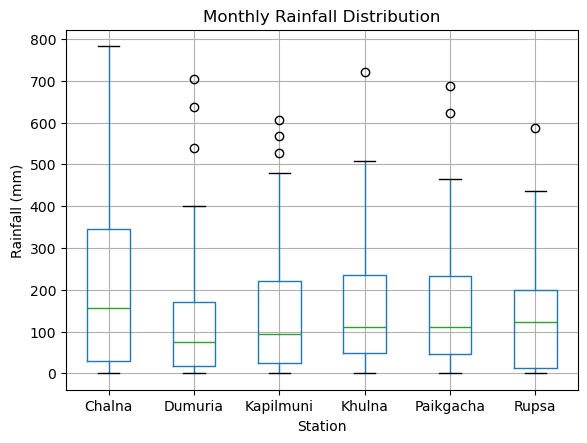

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

gauge_df.boxplot(
    column="rainfall_mm",
    by="station_name"
)

plt.title("Monthly Rainfall Distribution")
plt.suptitle("")
plt.xlabel("Station")
plt.ylabel("Rainfall (mm)")

plt.show()

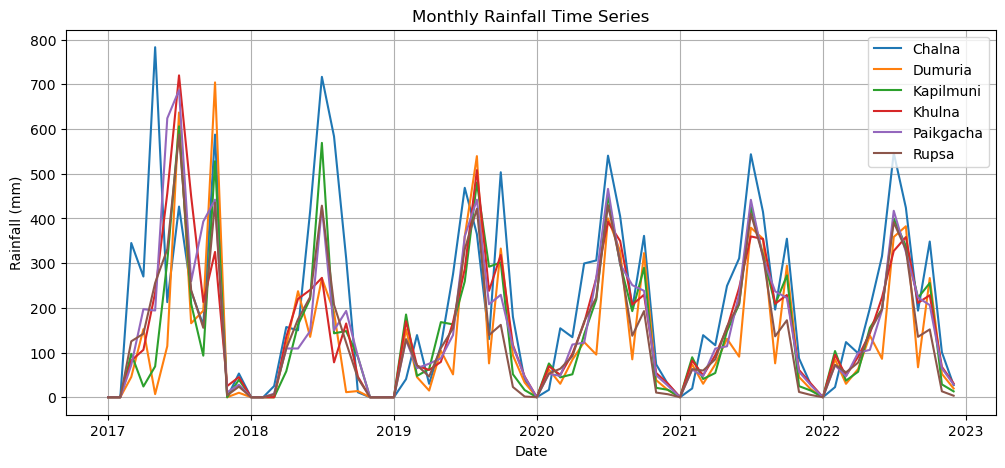

In [20]:
plt.figure(figsize=(12,5))

for station in gauge_df["station_name"].unique():

    subset = gauge_df[
        gauge_df["station_name"] == station
    ]

    plt.plot(
        subset["date"],
        subset["rainfall_mm"],
        label=station
    )

plt.legend()
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly Rainfall Time Series")

plt.grid(True)

plt.show()

In [22]:
# ==========================================================
# Create Final Clean GeoDataFrame
# ==========================================================

final_columns = [
    "station_id",
    "station_name",
    "latitude",
    "longitude",
    "year",
    "month",
    "date",
    "rainfall_mm",
    "geometry",
]

gauge_clean_gdf = (
    gauge_df[final_columns]
    .sort_values(
        ["station_id", "date"]
    )
    .reset_index(drop=True)
    .copy()
)

print("Rows:", len(gauge_clean_gdf))
print("CRS:", gauge_clean_gdf.crs)

gauge_clean_gdf.head()

Rows: 432
CRS: EPSG:4326


,station_id,station_name,latitude,longitude,year,month,date,rainfall_mm,geometry
0,CL503,Chalna,22.6012,89.5195,2017,1,2017-01-01,0.0,POINT (89.5195 22.6012)
1,CL503,Chalna,22.6012,89.5195,2017,2,2017-02-01,0.0,POINT (89.5195 22.6012)
2,CL503,Chalna,22.6012,89.5195,2017,3,2017-03-01,345.0,POINT (89.5195 22.6012)
3,CL503,Chalna,22.6012,89.5195,2017,4,2017-04-01,270.0,POINT (89.5195 22.6012)
4,CL503,Chalna,22.6012,89.5195,2017,5,2017-05-01,783.0,POINT (89.5195 22.6012)


In [23]:
# ==========================================================
# Station Summary
# ==========================================================

EXPECTED_MONTHS = 72

station_summary = (
    gauge_clean_gdf
    .groupby(
        ["station_id", "station_name"]
    )
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        total_records=("date", "count"),
        valid_rainfall=("rainfall_mm", "count"),
        missing_rainfall=(
            "rainfall_mm",
            lambda values: values.isna().sum()
        ),
        minimum_rainfall=("rainfall_mm", "min"),
        maximum_rainfall=("rainfall_mm", "max"),
        mean_rainfall=("rainfall_mm", "mean"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )
    .reset_index()
)

station_summary["completeness_percent"] = (
    station_summary["valid_rainfall"]
    / EXPECTED_MONTHS
    * 100
)

station_summary

,station_id,station_name,first_date,last_date,total_records,valid_rainfall,missing_rainfall,minimum_rainfall,maximum_rainfall,mean_rainfall,latitude,longitude,completeness_percent
0,CL503,Chalna,2017-01-01,2022-12-01,72,72,0,0.0,783.0,209.788889,22.6012,89.5195,100.0
1,CL504,Dumuria,2017-01-01,2022-12-01,72,72,0,0.0,704.3,131.883333,22.8093,89.4145,100.0
2,CL509,Kapilmuni,2017-01-01,2022-12-01,72,72,0,0.0,606.0,149.973611,22.6887,89.3088,100.0
3,CL510,Khulna,2017-01-01,2022-12-01,72,72,0,0.0,720.0,159.333333,22.8319,89.5500,100.0
4,CL515,Paikgacha,2017-01-01,2022-12-01,72,72,0,0.0,687.0,161.234722,22.5850,89.3182,100.0
5,CL517,Rupsa,2017-01-01,2022-12-01,72,72,0,0.0,587.5,140.090278,22.7900,89.5900,100.0


In [24]:
# ==========================================================
# Export Clean Gauge Data
# ==========================================================

GAUGE_OUTPUT = (
    PROJECT_ROOT
    / config["paths"]["processed_data"]
    / "gauge"
)

GAUGE_OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)

csv_output = (
    GAUGE_OUTPUT
    / "bmd_monthly_rainfall_2017_2022.csv"
)

gpkg_output = (
    GAUGE_OUTPUT
    / "bmd_monthly_rainfall_2017_2022.gpkg"
)

summary_output = (
    GAUGE_OUTPUT
    / "bmd_station_summary.csv"
)

# CSV without geometry
gauge_clean_gdf.drop(
    columns="geometry"
).to_csv(
    csv_output,
    index=False
)

# GeoPackage with geometry
gauge_clean_gdf.to_file(
    gpkg_output,
    layer="monthly_rainfall",
    driver="GPKG"
)

# Station summary
station_summary.to_csv(
    summary_output,
    index=False
)

print("Saved:", csv_output)
print("Saved:", gpkg_output)
print("Saved:", summary_output)

Saved: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\gauge\bmd_monthly_rainfall_2017_2022.csv
Saved: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\gauge\bmd_monthly_rainfall_2017_2022.gpkg
Saved: E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\gauge\bmd_station_summary.csv
